# Clasificador paisajes
Para este ejercicio vas a crear un clasificador automático de paisajes. Los datos los encontrarás en el Classroom como `seg_train.zip` y `seg_test.zip`. Se pide:
1. Cargar las imágenes. Mira cómo están almacenados los datos. Tendrás que recorrer las carpetas, cargar las imágenes en memoria y etiquetarlas con los nombres de las carpetas. Realiza un reshape de cada imagen (comienza el ejercicio con 32x32, para ir más rápido en las ejecuciones).
2. Investiga las imágenes, comprueba con algunas muestras que has cargado bien los datos.
3. Normaliza
4. Diseña la arquitectura de la red. Recuerda que es un algoritmo de clasificación. Ojo con las dimensiones de la entrada
5. Reserva un 20% de los datos del entrenamiento para validar.
6. Representa el objeto history
7. Evalua el modelo con los datos de test
8. Representa algunos de los paisajes donde el modelo comete errores
9. Crea una matriz de confusión con los errores del modelo

**NOTA apartado 1**: para el apartado 1 tendras que recorre las carpetas/imagenes con `os.listdir()`, e ir cargando todas las imagenes como arrays de numpy

**NOTA apartado 4**: empieza con un par de capas Conv2D + MaxPooling2D con activación relu y después la fully connected layer. on softmax como ultima capa

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import os
import cv2
from skimage.io import imread
from sklearn.utils import shuffle
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
import seaborn as sns
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from keras.callbacks import EarlyStopping, ModelCheckpoint

In [18]:
IMAGE_WIDTH   = 32
IMAGE_HEIGHT  = 32
IMAGE_CHANNELS = 3
IMAGE_SIZE    = (IMAGE_WIDTH, IMAGE_HEIGHT, IMAGE_CHANNELS)
BATCH_SIZE    = 32
EPOCHS        = 30

In [19]:
ROOT_PATH  = "C:\\Users\\rns_2\\Desktop\\Datasets\\clasificador_paisajes"
TRAIN_PATH = ROOT_PATH + "\\seg_train\\"
TEST_PATH  = ROOT_PATH + "\\seg_test\\"

## 1. Cargar imágenes

In [20]:
def read_data(path, im_size):
    X = []
    Y = []

    # Iteramos sobre las 6 carpetas (buildings, forest, glacier...)
    for category in os.listdir(path):
        carpeta_categoria = os.path.join(path, category)

        if not os.path.isdir(carpeta_categoria):
            continue

        # Iteramos sobre las imágenes dentro de cada carpeta
        for filename in os.listdir(carpeta_categoria):
            ruta = os.path.join(carpeta_categoria, filename)

            image = imread(ruta)
            smallimage = cv2.resize(image, (im_size, im_size))

            X.append(smallimage)
            Y.append(category)  # etiqueta = nombre de la carpeta

    return np.array(X), np.array(Y)


X_train, y_train = read_data(TRAIN_PATH, IMAGE_WIDTH)
X_test,  y_test  = read_data(TEST_PATH,  IMAGE_WIDTH)

print(f"Shape X_train: {X_train.shape}")
print(f"Shape y_train: {y_train.shape}")
print(f"Shape X_test:  {X_test.shape}")
print(f"Shape y_test:  {y_test.shape}")

Shape X_train: (14034, 32, 32, 3)
Shape y_train: (14034,)
Shape X_test:  (3000, 32, 32, 3)
Shape y_test:  (3000,)


## 2. Investigar las imágenes

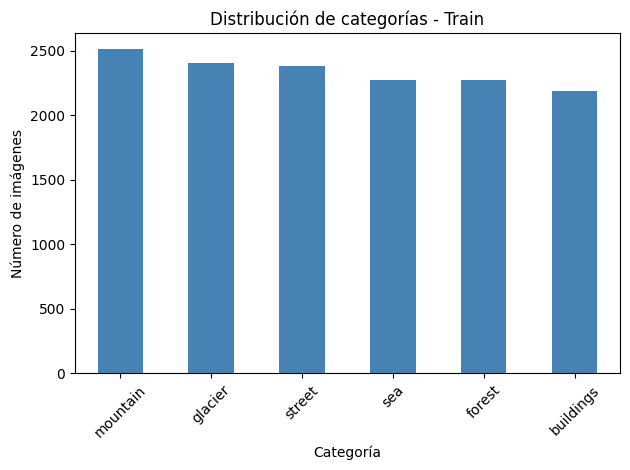

In [21]:
# Distribución de categorías
pd.Series(y_train).value_counts().plot.bar(color='steelblue')
plt.title('Distribución de categorías - Train')
plt.xlabel('Categoría')
plt.ylabel('Número de imágenes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

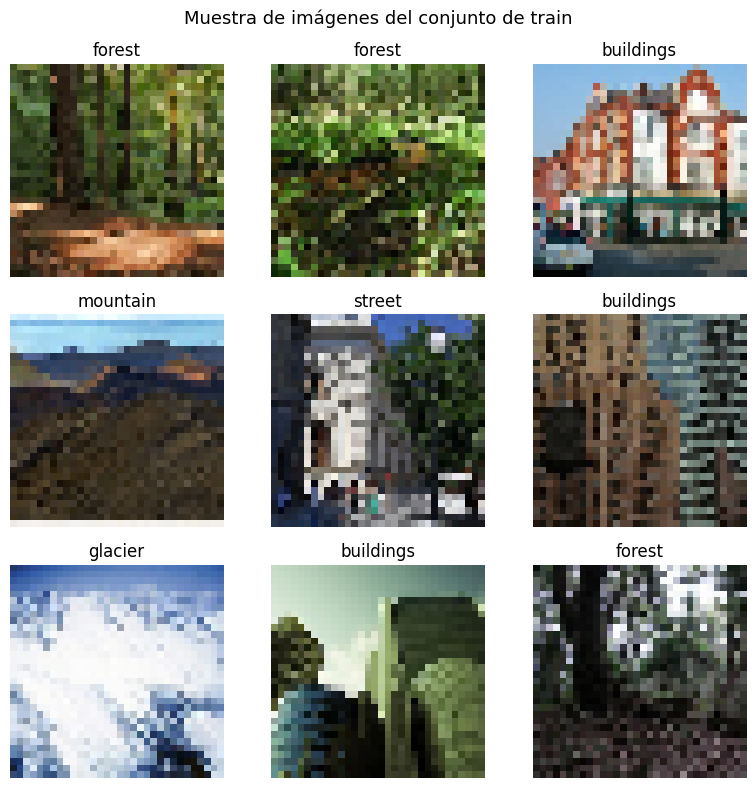

In [22]:
# Mostramos 9 imágenes aleatorias con su etiqueta
fig, axes = plt.subplots(3, 3, figsize=(8, 8))

for ax in axes.flatten():
    i = random.randint(0, len(X_train) - 1)
    ax.imshow(X_train[i].astype('uint8'))
    ax.set_title(y_train[i])
    ax.axis('off')

plt.suptitle('Muestra de imágenes del conjunto de train', fontsize=13)
plt.tight_layout()
plt.show()

## 3. Normalizar

In [23]:
# Dividimos entre 255 para que los píxeles queden en rango [0, 1]
X_train = X_train / 255.0
X_test  = X_test  / 255.0

print(f"Min: {X_train.min()} | Max: {X_train.max()}")

Min: 0.0 | Max: 1.0


In [24]:
# Shuffle para evitar sesgos en el entrenamiento
X_train, y_train = shuffle(X_train, y_train, random_state=42)

In [25]:
# Encoding de etiquetas: strings -> números -> one-hot
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded  = le.transform(y_test)

y_train_cat = to_categorical(y_train_encoded, num_classes=6)
y_test_cat  = to_categorical(y_test_encoded,  num_classes=6)

print(f"Clases: {le.classes_}")
print(f"Shape y_train_cat: {y_train_cat.shape}")

Clases: ['buildings' 'forest' 'glacier' 'mountain' 'sea' 'street']
Shape y_train_cat: (14034, 6)


## 4. Construir el modelo

Arquitectura: **2 bloques Conv2D + MaxPooling2D** seguidos de una **Fully Connected Layer** con Dropout y salida **softmax** de 6 neuronas.

In [26]:
model = Sequential([
    # Bloque 1
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMAGE_WIDTH, IMAGE_HEIGHT, IMAGE_CHANNELS)),
    MaxPooling2D(2, 2),

    # Bloque 2
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    # Fully connected
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='softmax')  # 6 categorías
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

c:\Users\rns_2\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,206 (1.20 MB)

 Trainable params: 315,206 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Entrenar (con 20% de validación)

In [27]:
earlystop   = EarlyStopping(patience=10)
mcheckpoint = ModelCheckpoint("mejor_modelo.keras", save_best_only=True)

history = model.fit(
    X_train, y_train_cat,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=[earlystop, mcheckpoint]
)

Epoch 1/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.5244 - loss: 1.2075 - val_accuracy: 0.6587 - val_loss: 0.9197
Epoch 2/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6534 - loss: 0.9283 - val_accuracy: 0.7025 - val_loss: 0.8046
Epoch 3/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7040 - loss: 0.8182 - val_accuracy: 0.7282 - val_loss: 0.7243
Epoch 4/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7433 - loss: 0.7328 - val_accuracy: 0.7349 - val_loss: 0.7023
Epoch 5/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7503 - loss: 0.6932 - val_accuracy: 0.7617 - val_loss: 0.6586
Epoch 6/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7703 - loss: 0.6387 - val_accuracy: 0.7606 - val_loss: 0.6810
Epoch 7/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7843 - loss: 0.6042 - val_accuracy: 0.7545 - val_loss: 0.7006
Epoch 8/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7972 - loss: 0.5667 - val_accuracy: 0.

## 6. Representar el objeto history

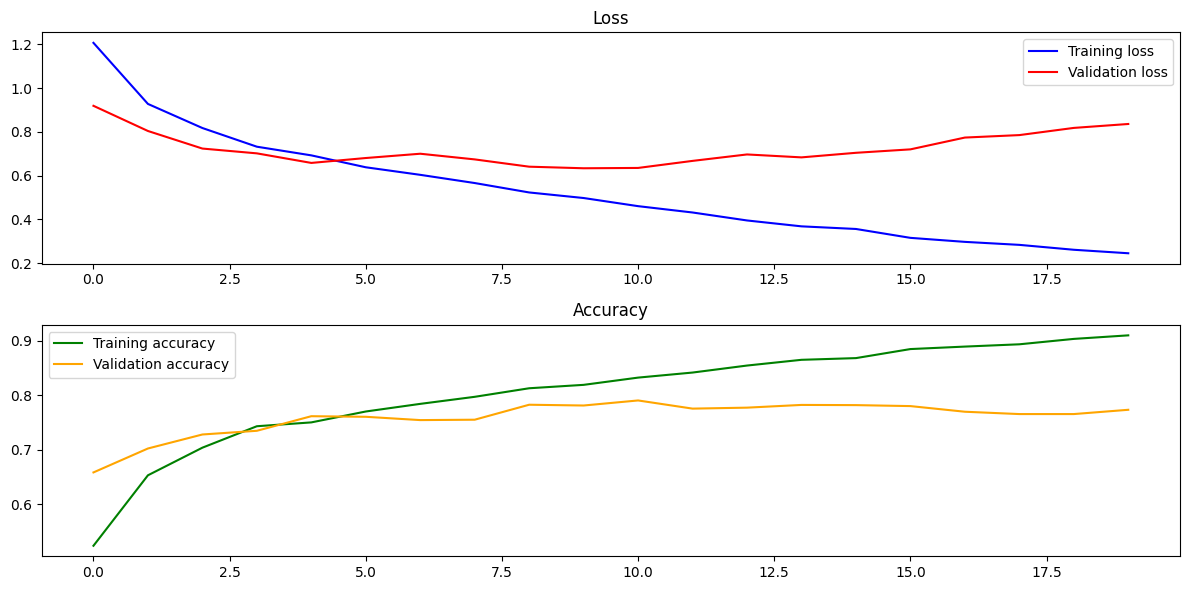

In [28]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))

ax1.plot(history.history['loss'],     color='b',      label='Training loss')
ax1.plot(history.history['val_loss'], color='r',      label='Validation loss')
ax1.set_title('Loss')
ax1.legend()

ax2.plot(history.history['accuracy'],     color='g',      label='Training accuracy')
ax2.plot(history.history['val_accuracy'], color='orange', label='Validation accuracy')
ax2.set_title('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

## 7. Evaluar el modelo con datos de test

In [29]:
results = model.evaluate(X_test, y_test_cat, verbose=1)
print(f"\nTest loss:     {results[0]:.4f}")
print(f"Test accuracy: {results[1]:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7723 - loss: 0.7991

Test loss:     0.7991
Test accuracy: 0.7723


## 8. Paisajes donde el modelo comete errores

In [30]:
# Obtenemos predicciones
y_pred_probs = model.predict(X_test)
y_pred       = np.argmax(y_pred_probs, axis=1)  # clase predicha
y_true       = y_test_encoded                   # clase real

# Índices donde el modelo se equivoca
errores = np.where(y_pred != y_true)[0]
print(f"Total errores: {len(errores)} de {len(y_true)} imágenes")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Total errores: 683 de 3000 imágenes


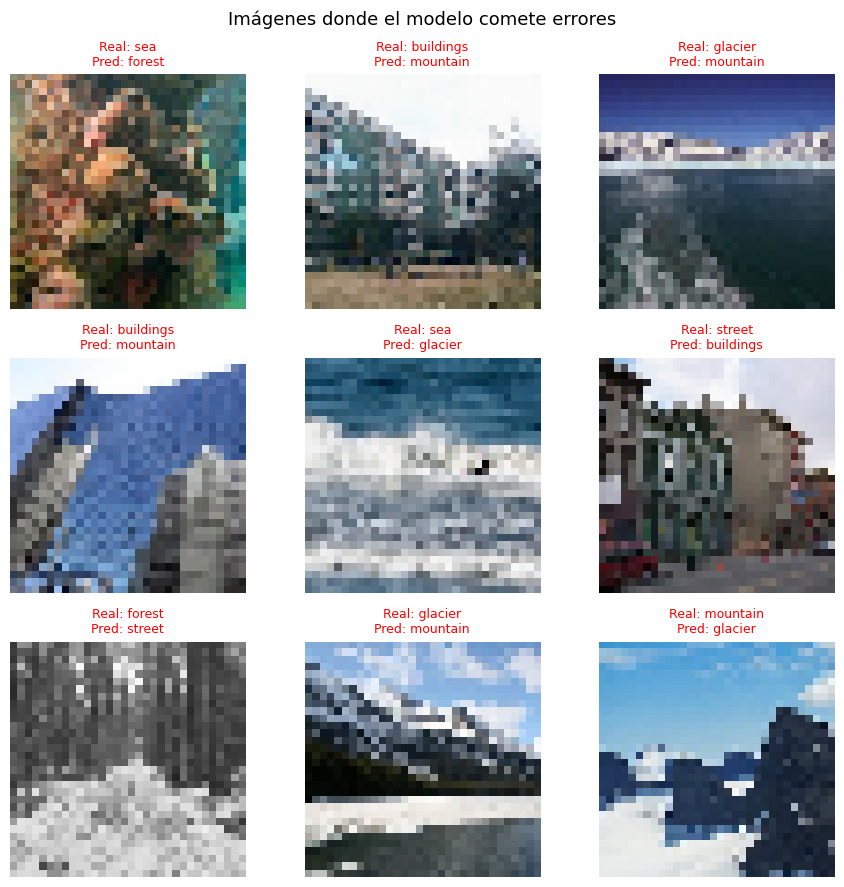

In [31]:
# Mostramos 9 ejemplos de error
muestra_errores = random.sample(list(errores), min(9, len(errores)))

fig, axes = plt.subplots(3, 3, figsize=(9, 9))

for ax, idx in zip(axes.flatten(), muestra_errores):
    ax.imshow(X_test[idx])
    ax.set_title(
        f"Real: {le.classes_[y_true[idx]]}\nPred: {le.classes_[y_pred[idx]]}",
        fontsize=9, color='red'
    )
    ax.axis('off')

plt.suptitle('Imágenes donde el modelo comete errores', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Matriz de confusión

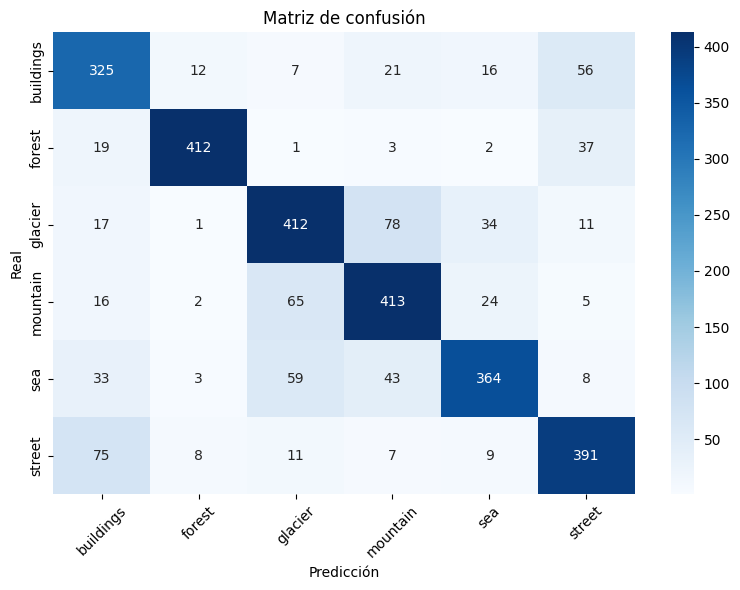

In [32]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title('Matriz de confusión')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()